In [ ]:
import pandas as pd
log_path = r'27_07\prueba_01.csv'
df_log = pd.read_csv(log_path, dtype=str)
df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1785190756781,41460E0000000000,88D0AA01,0781A033,662D0000,12000000,4C000000,6E730000,00000000,00000000,00000000,47FFFFFF,41460E000000000088D0AA010781A033662D0000120000...
1,1785190756781,A5460E0000000000,88D0AA01,0781A033,662D0000,12000000,4C000000,6E730000,00000000,00000000,00000000,47FFFFFF,A5460E000000000088D0AA010781A033662D0000120000...
2,1785190756781,09470E0000000000,88D0AA01,0781A033,662D0000,12000000,4C000000,6E730000,00000000,00000000,00000000,47FFFFFF,09470E000000000088D0AA010781A033662D0000120000...
3,1785190756781,6D470E0000000000,88D0AA01,0781A033,662D0000,12000000,4C000000,6E730000,00000000,00000000,00000000,47FFFFFF,6D470E000000000088D0AA010781A033662D0000120000...
4,1785190756781,D2470E0000000000,88D0AA01,0781A033,662D0000,12000000,4C000000,6E730000,00000000,00000000,00000000,47FFFFFF,D2470E000000000088D0AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,1785191010781,9E26120000000000,6FCBAA01,3A8CA033,662D0000,12000000,4C000000,62720000,870B0000,93F7FFFF,AFD2FFFF,42FEFFFF,9E261200000000006FCBAA013A8CA033662D0000120000...
2515,1785191010781,0227120000000000,6FCBAA01,3A8CA033,662D0000,12000000,4C000000,62720000,870B0000,93F7FFFF,AFD2FFFF,42FEFFFF,02271200000000006FCBAA013A8CA033662D0000120000...
2516,1785191010781,6627120000000000,6FCBAA01,3A8CA033,662D0000,12000000,4C000000,62720000,870B0000,93F7FFFF,AFD2FFFF,42FEFFFF,66271200000000006FCBAA013A8CA033662D0000120000...
2517,1785191010781,CA27120000000000,6FCBAA01,3A8CA033,662D0000,12000000,4C000000,62720000,870B0000,93F7FFFF,AFD2FFFF,42FEFFFF,CA271200000000006FCBAA013A8CA033662D0000120000...


In [ ]:
# Columnas hexadecimales little-endian (excluimos 'time' que ya es decimal, y 'raw' que es la concatenación)
hex_cols = [c for c in df_log.columns if c not in ("time", "raw")]

def hex_to_int(x):
    return int.from_bytes(bytes.fromhex(x), byteorder="little", signed=True)

for column in hex_cols:
    df_log[column] = df_log[column].apply(hex_to_int)

# 'time' es epoch en ms (entero decimal), lo convertimos aparte
df_log["time"] = df_log["time"].astype("int64")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1785190756781,935489,27971720,866156807,11622,18,76,29550,0,0,0,-185,41460E000000000088D0AA010781A033662D0000120000...
1,1785190756781,935589,27971720,866156807,11622,18,76,29550,0,0,0,-185,A5460E000000000088D0AA010781A033662D0000120000...
2,1785190756781,935689,27971720,866156807,11622,18,76,29550,0,0,0,-185,09470E000000000088D0AA010781A033662D0000120000...
3,1785190756781,935789,27971720,866156807,11622,18,76,29550,0,0,0,-185,6D470E000000000088D0AA010781A033662D0000120000...
4,1785190756781,935890,27971720,866156807,11622,18,76,29550,0,0,0,-185,D2470E000000000088D0AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,1785191010781,1189534,27970415,866159674,11622,18,76,29282,2951,-2157,-11601,-446,9E261200000000006FCBAA013A8CA033662D0000120000...
2515,1785191010781,1189634,27970415,866159674,11622,18,76,29282,2951,-2157,-11601,-446,02271200000000006FCBAA013A8CA033662D0000120000...
2516,1785191010781,1189734,27970415,866159674,11622,18,76,29282,2951,-2157,-11601,-446,66271200000000006FCBAA013A8CA033662D0000120000...
2517,1785191010781,1189834,27970415,866159674,11622,18,76,29282,2951,-2157,-11601,-446,CA271200000000006FCBAA013A8CA033662D0000120000...


In [ ]:
# Escalado a unidades reales (confirmado contra ControlBox_prueba1.db y por consistencia interna)
# Todos los enteros vienen en centesimas (valor x100): posicion/altura en cm, angulos en centesimas de grado.
#   z=11622 -> 116.22 (IBeacon.altitude), heading=29549 -> 295.49 (HeadingBeacon=295.5)
#   inx_x=99985 -> 999.85 m ~= distancia UTM recorrida (~993 m)
#   inx_yaw=-136 -> -1.36 deg ~= variacion de heading (-1.23 deg)

df_log["utm_x"]   = df_log["utm_x"] / 100.0        # m (UTM Este)
df_log["utm_y"]   = df_log["utm_y"] / 100.0        # m (UTM Norte)
df_log["z"]       = df_log["z"] / 100.0            # m (altura)
df_log["heading"] = df_log["heading"] / 100.0      # grados

df_log["utm_zone_l"] = df_log["utm_zone_l"].apply(chr)   # 76 -> 'L'
# utm_zone_n queda como entero (18)

# Offsets INS relativos a la baliza (mismo factor: centesimas)
df_log["inx_x"]   = df_log["inx_x"] / 100.0        # m
df_log["inx_y"]   = df_log["inx_y"] / 100.0        # m
df_log["inx_z"]   = df_log["inx_z"] / 100.0        # m
df_log["inx_yaw"] = df_log["inx_yaw"] / 100.0      # grados

# time a datetime (epoch ms)
df_log["time"] = pd.to_datetime(df_log["time"], unit="ms")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,2026-07-27 22:19:16.781,935489,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,41460E000000000088D0AA010781A033662D0000120000...
1,2026-07-27 22:19:16.781,935589,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,A5460E000000000088D0AA010781A033662D0000120000...
2,2026-07-27 22:19:16.781,935689,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,09470E000000000088D0AA010781A033662D0000120000...
3,2026-07-27 22:19:16.781,935789,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,6D470E000000000088D0AA010781A033662D0000120000...
4,2026-07-27 22:19:16.781,935890,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,D2470E000000000088D0AA010781A033662D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,2026-07-27 22:23:30.781,1189534,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,9E261200000000006FCBAA013A8CA033662D0000120000...
2515,2026-07-27 22:23:30.781,1189634,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,02271200000000006FCBAA013A8CA033662D0000120000...
2516,2026-07-27 22:23:30.781,1189734,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,66271200000000006FCBAA013A8CA033662D0000120000...
2517,2026-07-27 22:23:30.781,1189834,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,CA271200000000006FCBAA013A8CA033662D0000120000...


In [ ]:
df_log.to_csv("verificacion_ins.csv", index=False)

In [ ]:
def plot_window(df, ts_array="t_rel", data_array=None):# plt.figure(figsize=(10, 5))
    plt.plot(df[ts_array], df[data_array], label=data_array)
    # plt.xlabel("Hora")
    # plt.ylabel("Velocidad [km/h]")
    # plt.title("Velocidad vehicular OBD-II sincronizada")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

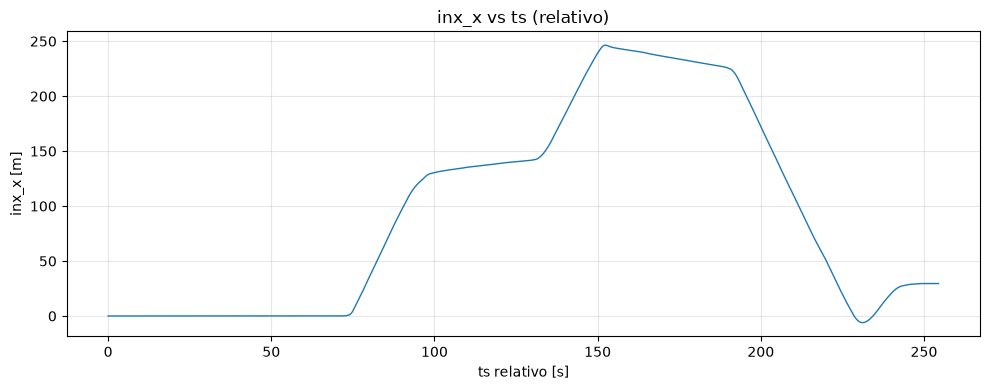

In [ ]:
import matplotlib.pyplot as plt

# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

# 1) inx_x vs ts (relativo)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_rel, df_log["inx_x"], lw=1)
ax.set_xlabel("ts relativo [s]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_x vs ts (relativo)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

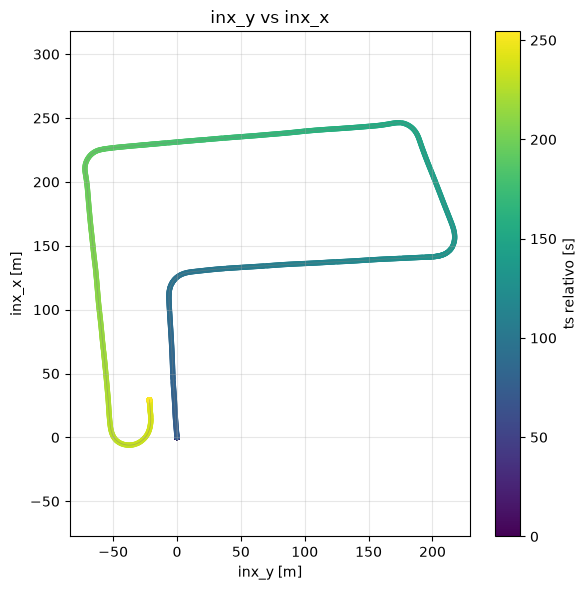

In [ ]:
# 2) inx_x vs inx_y (trayectoria en el plano local del INS)
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_log["inx_y"], df_log["inx_x"], c=t_rel, cmap="viridis", s=8)
ax.plot(df_log["inx_y"], df_log["inx_x"], lw=0.5, color="gray", alpha=0.5)
ax.set_xlabel("inx_y [m]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_y vs inx_x")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="ts relativo [s]")
plt.tight_layout()
plt.show()

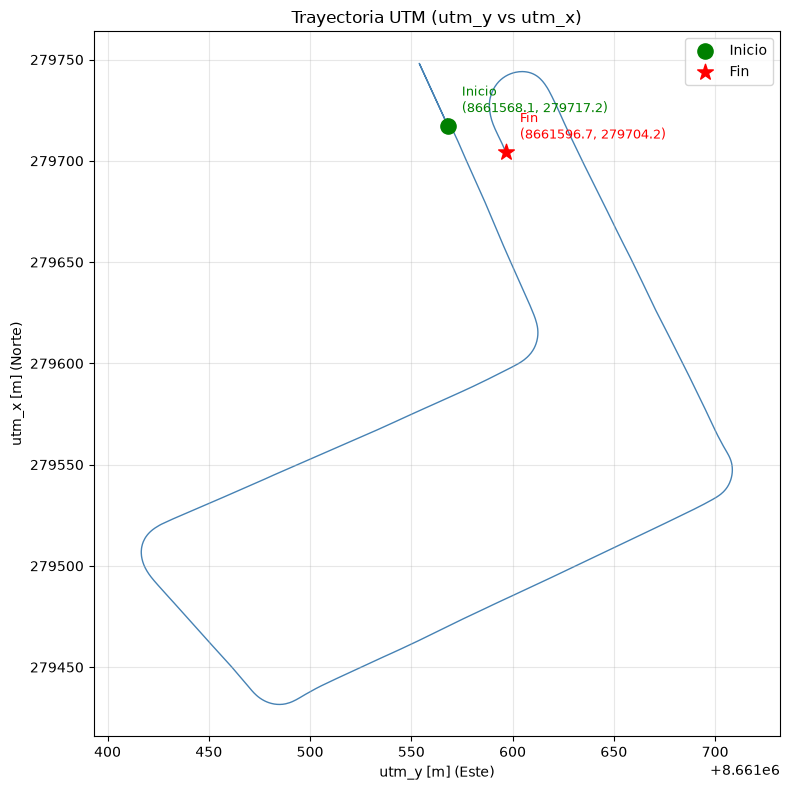

In [ ]:
# Trayectoria UTM con identificadores de inicio y fin
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(df_log["utm_y"], df_log["utm_x"], lw=1, color="steelblue", zorder=1)

# Punto inicial y final
x0, y0 = df_log["utm_y"].iloc[0],  df_log["utm_x"].iloc[0]
xf, yf = df_log["utm_y"].iloc[-1], df_log["utm_x"].iloc[-1]

ax.scatter(x0, y0, color="green", s=120, marker="o", zorder=3, label="Inicio")
ax.scatter(xf, yf, color="red",   s=140, marker="*", zorder=3, label="Fin")

ax.annotate(f"Inicio\n({x0:.1f}, {y0:.1f})", (x0, y0),
            textcoords="offset points", xytext=(10, 10), color="green", fontsize=9)
ax.annotate(f"Fin\n({xf:.1f}, {yf:.1f})", (xf, yf),
            textcoords="offset points", xytext=(10, 10), color="red", fontsize=9)

ax.set_xlabel("utm_y [m] (Este)")
ax.set_ylabel("utm_x [m] (Norte)")
ax.set_title("Trayectoria UTM (utm_y vs utm_x)")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
np.sqrt((278821.8 - 279717.5) **2 + (8661997.3 - 8661568.1)**2)

np.float64(993.2225984143636)

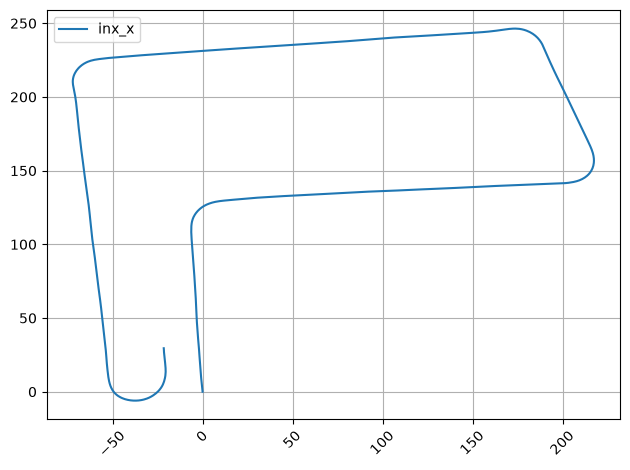

In [ ]:
plot_window(df_log, ts_array="inx_y", data_array="inx_x")

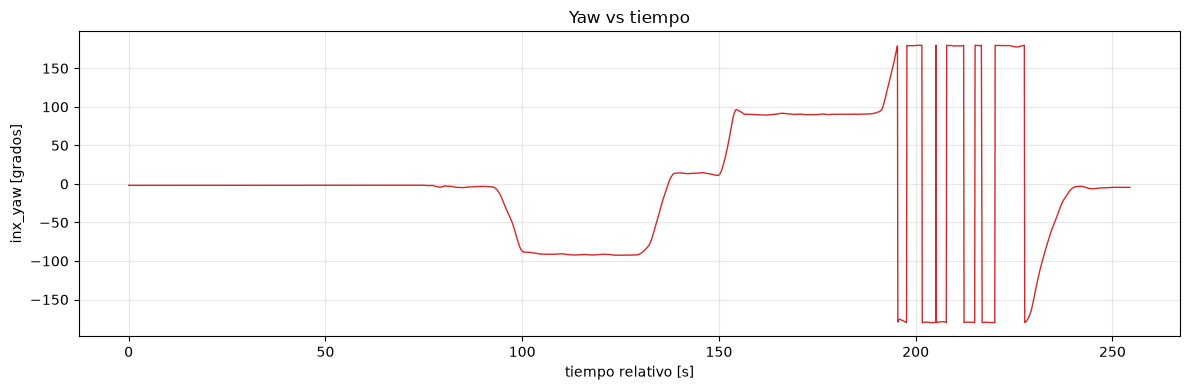

In [ ]:
# yaw (inx_yaw) vs tiempo
# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rel, df_log["inx_yaw"], lw=1, color="tab:red")
ax.set_xlabel("tiempo relativo [s]")
ax.set_ylabel("inx_yaw [grados]")
ax.set_title("Yaw vs tiempo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_log["inx_yaw_corr"] = -df_log["inx_yaw"]
df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw,inx_yaw_corr
0,2026-07-27 22:19:16.781,935489,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,41460E000000000088D0AA010781A033662D0000120000...,1.85
1,2026-07-27 22:19:16.781,935589,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,A5460E000000000088D0AA010781A033662D0000120000...,1.85
2,2026-07-27 22:19:16.781,935689,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,09470E000000000088D0AA010781A033662D0000120000...,1.85
3,2026-07-27 22:19:16.781,935789,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,6D470E000000000088D0AA010781A033662D0000120000...,1.85
4,2026-07-27 22:19:16.781,935890,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,D2470E000000000088D0AA010781A033662D0000120000...,1.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,2026-07-27 22:23:30.781,1189534,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,9E261200000000006FCBAA013A8CA033662D0000120000...,4.46
2515,2026-07-27 22:23:30.781,1189634,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,02271200000000006FCBAA013A8CA033662D0000120000...,4.46
2516,2026-07-27 22:23:30.781,1189734,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,66271200000000006FCBAA013A8CA033662D0000120000...,4.46
2517,2026-07-27 22:23:30.781,1189834,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,CA271200000000006FCBAA013A8CA033662D0000120000...,4.46


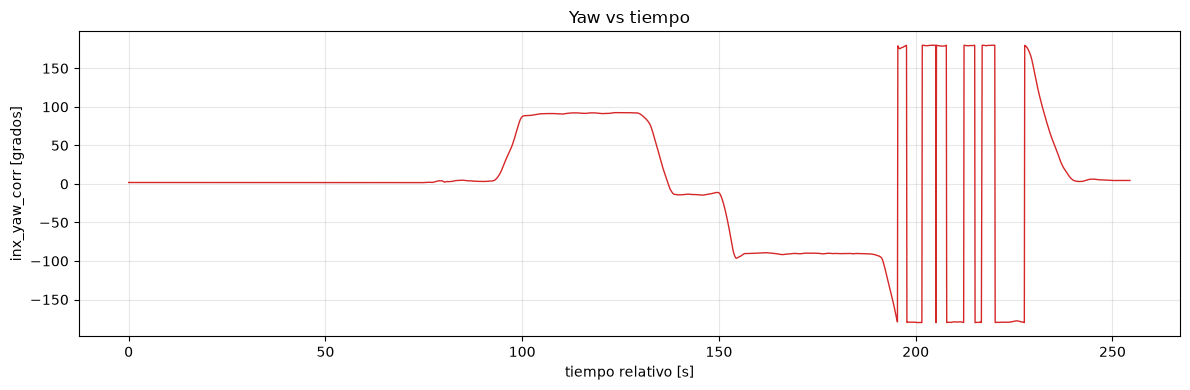

In [ ]:
# yaw (inx_yaw) vs tiempo
# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rel, df_log["inx_yaw_corr"], lw=1, color="tab:red")
ax.set_xlabel("tiempo relativo [s]")
ax.set_ylabel("inx_yaw_corr [grados]")
ax.set_title("Yaw vs tiempo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Rotacion de inx_x, inx_y ---

# 1) yaw relativo: resta el primer yaw corregido (offset inicial)
df_log["inx_yaw_rel"] = df_log["inx_yaw_corr"] - df_log["inx_yaw_corr"].iloc[0]

# 2) aplica la correccion del heading del beacon (295.5 sobre el Norte)
BEACON_HEADING = - (360 - 295.5)
df_log["ned_yaw_rel"] = BEACON_HEADING + df_log["inx_yaw_rel"]

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw,inx_yaw_corr,inx_yaw_rel,ned_yaw_rel
0,2026-07-27 22:19:16.781,935489,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,41460E000000000088D0AA010781A033662D0000120000...,1.85,0.00,-64.50
1,2026-07-27 22:19:16.781,935589,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,A5460E000000000088D0AA010781A033662D0000120000...,1.85,0.00,-64.50
2,2026-07-27 22:19:16.781,935689,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,09470E000000000088D0AA010781A033662D0000120000...,1.85,0.00,-64.50
3,2026-07-27 22:19:16.781,935789,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,6D470E000000000088D0AA010781A033662D0000120000...,1.85,0.00,-64.50
4,2026-07-27 22:19:16.781,935890,279717.20,8661568.07,116.22,18,L,295.50,0.00,0.00,0.00,-1.85,D2470E000000000088D0AA010781A033662D0000120000...,1.85,0.00,-64.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,2026-07-27 22:23:30.781,1189534,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,9E261200000000006FCBAA013A8CA033662D0000120000...,4.46,2.61,-61.89
2515,2026-07-27 22:23:30.781,1189634,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,02271200000000006FCBAA013A8CA033662D0000120000...,4.46,2.61,-61.89
2516,2026-07-27 22:23:30.781,1189734,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,66271200000000006FCBAA013A8CA033662D0000120000...,4.46,2.61,-61.89
2517,2026-07-27 22:23:30.781,1189834,279704.15,8661596.74,116.22,18,L,292.82,29.51,-21.57,-116.01,-4.46,CA271200000000006FCBAA013A8CA033662D0000120000...,4.46,2.61,-61.89


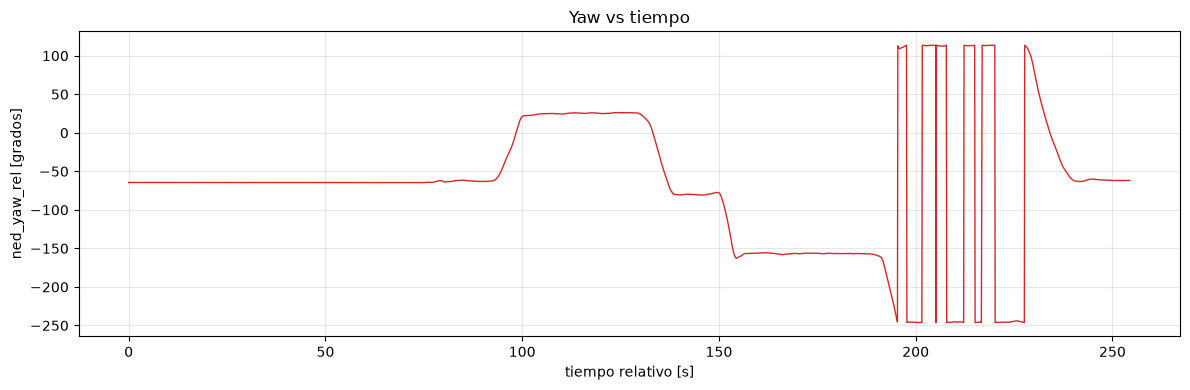

In [ ]:
# yaw (inx_yaw) vs tiempo
# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rel, df_log["ned_yaw_rel"], lw=1, color="tab:red")
ax.set_xlabel("tiempo relativo [s]")
ax.set_ylabel("ned_yaw_rel [grados]")
ax.set_title("Yaw vs tiempo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# theta = np.radians(theta_deg)
# 3) rota (inx_x, inx_y) por theta
df_log["inx_x_rot"] = df_log["inx_x"] * np.cos(np.radians(df_log["ned_yaw_rel"])) - df_log["inx_y"] * np.sin(np.radians(df_log["ned_yaw_rel"]))
df_log["inx_y_rot"] = df_log["inx_x"] * np.sin(np.radians(df_log["ned_yaw_rel"])) + df_log["inx_y"] * np.cos(np.radians(df_log["ned_yaw_rel"]))

df_log[["inx_x", "inx_y", "inx_yaw_corr", "inx_x_rot", "inx_y_rot"]]

In [ ]:
plot_window(df_log, ts_array="inx_y_rot", data_array="inx_x_rot")

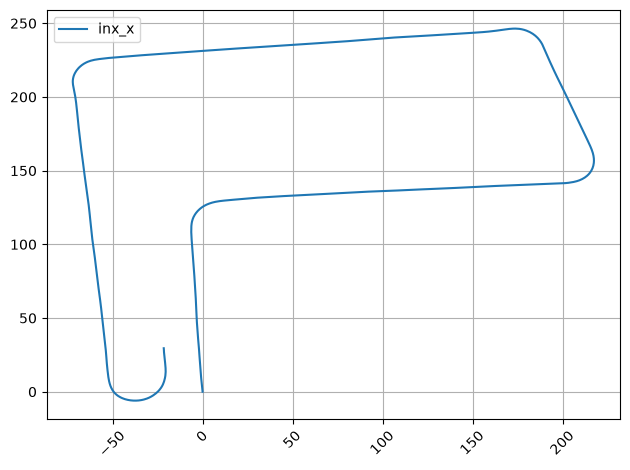

In [ ]:
plot_window(df_log, ts_array="inx_y", data_array="inx_x")